In [10]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt
import ast
import seaborn as sns

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [11]:
df = pd.read_csv('../../data/transcript_portfolio_profile.csv')
rc = pd.read_csv('../../data/coversion.csv')

In [12]:
con = rc[['customer_id', 'offer_id', 'converted_final']]
con.head()

,customer_id,offer_id,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,1
1,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,1
2,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,1
3,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,0
4,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,0


In [13]:
df['became_member_on'] = pd.to_datetime(df['became_member_on'], format='%Y-%m-%d')

In [14]:
df['became_member_on'].describe()

count                        272370
mean     2016-12-21 18:05:42.751404
min             2013-07-29 00:00:00
25%             2016-03-16 00:00:00
50%             2017-04-11 00:00:00
75%             2017-11-26 00:00:00
max             2018-07-26 00:00:00
Name: became_member_on, dtype: object

In [15]:
df['membership_year'] = df['became_member_on'].dt.year.astype('Int64')

In [16]:
df.head()

,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing,membership_year
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1,2017
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaT,0,<NA>
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1,2018
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaT,0,<NA>
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaT,0,<NA>


In [17]:
df.groupby('membership_year')['customer_id'].nunique()

membership_year
2013     274
2014     661
2015    1597
2016    3024
2017    5599
2018    3669
Name: customer_id, dtype: int64

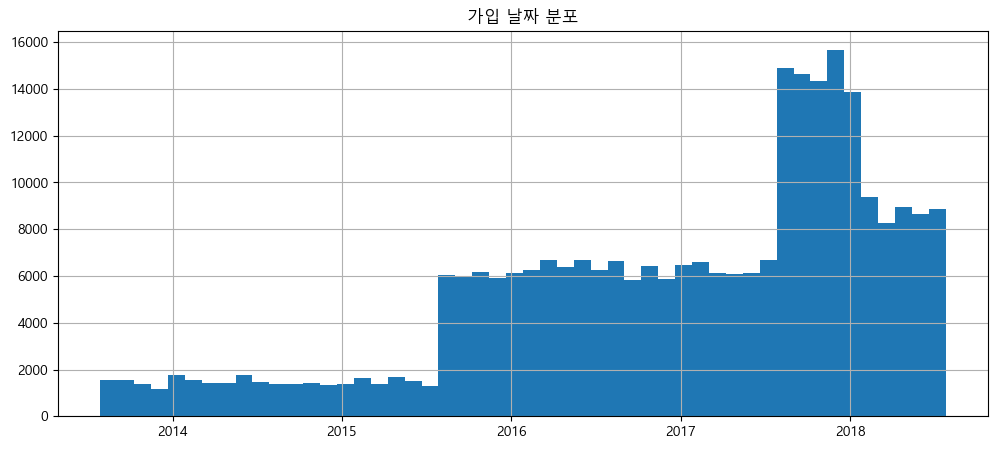

In [18]:
df['became_member_on'].hist(bins=50, figsize=(12, 5))
plt.title('가입 날짜 분포')
plt.show()

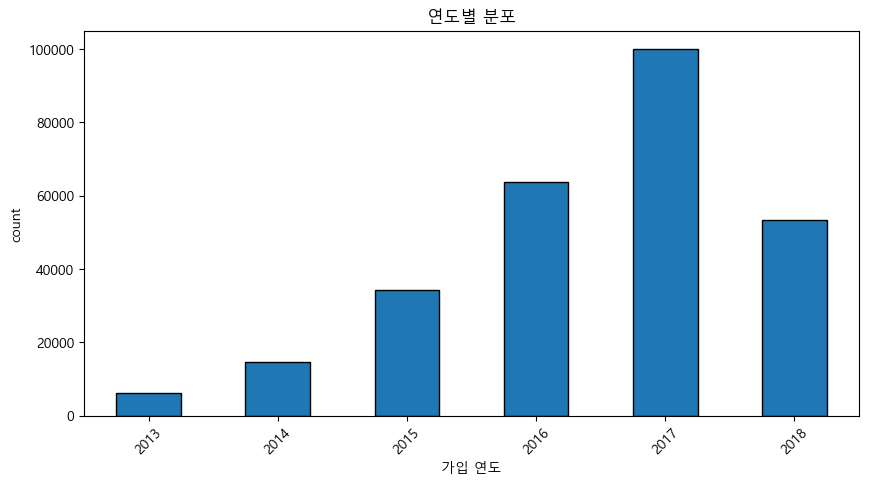

In [19]:
df['membership_year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5), edgecolor = 'black')
plt.title('연도별 분포')
plt.xlabel('가입 연도')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.show()

In [20]:
# con 구조 확인
print(con.head())
print(con.shape)
print(con.columns.tolist())

                        customer_id                          offer_id  \
0  0009655768c64bdeb2e877511632db8f  2906b810c7d4411798c6938adc9daaa5   
1  0009655768c64bdeb2e877511632db8f  f19421c1d4aa40978ebb69ca19b0e20d   
2  0009655768c64bdeb2e877511632db8f  fafdcd668e3743c1bb461111dcafc2a4   
3  00116118485d4dfda04fdbaba9a87b5c  f19421c1d4aa40978ebb69ca19b0e20d   
4  00116118485d4dfda04fdbaba9a87b5c  f19421c1d4aa40978ebb69ca19b0e20d   

   converted_final  
0                1  
1                1  
2                1  
3                0  
4                0  
(61042, 3)
['customer_id', 'offer_id', 'converted_final']


In [21]:
# customer_id + offer_id 조합별로 converted_final 고유값 개수 확인
check = con.groupby(['customer_id', 'offer_id'])['converted_final'].nunique()

# 고유값이 2개 이상이면 같은 조합에서 값이 다른 것
print(check[check > 1])
print(f"\n값이 다른 조합 수: {(check > 1).sum()}")


customer_id                       offer_id                        
0069a50874d846438e58acff5e594725  2906b810c7d4411798c6938adc9daaa5    2
00840a2ca5d2408e982d56544dc14ffd  2906b810c7d4411798c6938adc9daaa5    2
0091d2b6a5ea4defaa8393e4e816db60  4d5c57ea9a6940dd891ad53e9dbe8da0    2
00c2f812f4604c8893152a5c6572030e  4d5c57ea9a6940dd891ad53e9dbe8da0    2
00cf1bbec83f4a658f8994e556db4633  fafdcd668e3743c1bb461111dcafc2a4    2
                                                                     ..
ff95e0a9cdfd4030958762dadcb11e1a  0b1e1539f2cc45b7b9fa7c272da2e1d7    2
ff9beda564da4bab81633fca744037dc  9b98b8c7a33c4b65b9aebfe6a799e6d9    2
ffac285a64714aca8efd8d61a5606e84  9b98b8c7a33c4b65b9aebfe6a799e6d9    2
ffe5257abf8840b395e1ee6b29894637  0b1e1539f2cc45b7b9fa7c272da2e1d7    2
fff3ba4757bd42088c044ca26d73817a  2906b810c7d4411798c6938adc9daaa5    2
Name: converted_final, Length: 2635, dtype: int64

값이 다른 조합 수: 2635


In [22]:
# con에서 customer_id + offer_id 기준으로 중복 제거


df2 = con.merge(df, how = 'left', on = ['customer_id', 'offer_id'])

In [23]:
print(df.shape)   # 원본 행 수
print(df2.shape)  # merge 후 행 수 → 크게 늘어나면 중복 문제
print(df2['converted_final'].isna().sum())  # 매칭 안 된 행 수

(306137, 21)
(193681, 22)
0


In [24]:
con_year = df2[df2['profile_missing'] == 1].groupby('membership_year', dropna=False)['converted_final'].mean()
print(con_year)

membership_year
2013    0.667938
2014    0.651026
2015    0.812754
2016    0.871144
2017    0.697012
2018    0.484724
Name: converted_final, dtype: float64


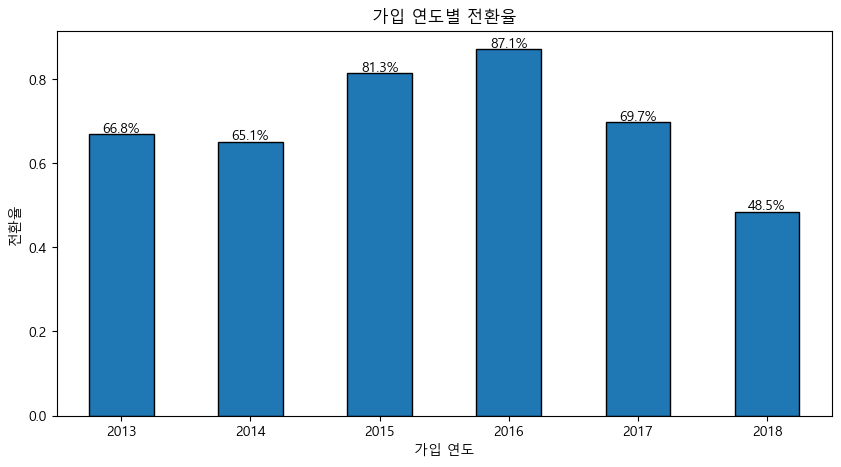

In [25]:
plt.figure(figsize = (10, 5))
con_year.plot(kind = 'bar', edgecolor = 'black')
plt.xlabel('가입 연도')
plt.ylabel('전환율')
plt.title('가입 연도별 전환율')
plt.xticks(rotation=0)

for i, v in enumerate(con_year):
    plt.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=10)

plt.show()

* 2018년에 가입한 사람은 가입한지 얼마 안 된 고객이라 오퍼에 덜 반응한 것일 수도 있음

In [26]:
df2.groupby('profile_missing')['converted_final'].mean() ## profile이 없는 대상은 전환율이 19%로 매우 낮음

profile_missing
0.0    0.189870
1.0    0.699094
Name: converted_final, dtype: float64

In [27]:
df2.groupby(['membership_year', 'offer_type'])['converted_final'].count().unstack()

offer_type,bogo,discount
membership_year,,
2013,1581,1566
2014,3657,3802
2015,10094,9805
2016,19164,19251
2017,33459,31372
2018,19320,19302


In [28]:
# 연도별 × 오퍼 타입별 전환율
offer_year = df2.groupby(['membership_year', 'offer_type'])['converted_final'].mean().unstack() * 100
offer_year

offer_type,bogo,discount
membership_year,,
2013,53.130930,80.587484
2014,50.013672,79.615992
2015,76.114523,86.588475
2016,84.209977,90.005714
2017,66.433546,73.186281
2018,44.787785,52.160398


In [29]:
# 연도별 평균 난이도/보상
diff_reward = df2.groupby('membership_year')[['difficulty', 'offer_reward']].mean() 
diff_reward

,difficulty,offer_reward
membership_year,,
2013,9.159517,5.179536
2014,9.232471,5.143451
2015,9.286597,5.184029
2016,9.373864,5.213849
2017,9.232235,5.283676
2018,9.326679,5.226736


In [30]:
gender_year = df2.groupby(['membership_year', 'gender'])['converted_final'].mean().unstack() * 100
gender_year

gender,F,M,O
membership_year,,,
2013,74.126638,63.710407,71.428571
2014,67.915408,64.289424,66.666667
2015,87.035739,76.357300,91.224018
2016,89.206969,84.765140,93.975904
2017,77.458370,63.122139,72.075055
2018,58.183966,42.100127,64.285714


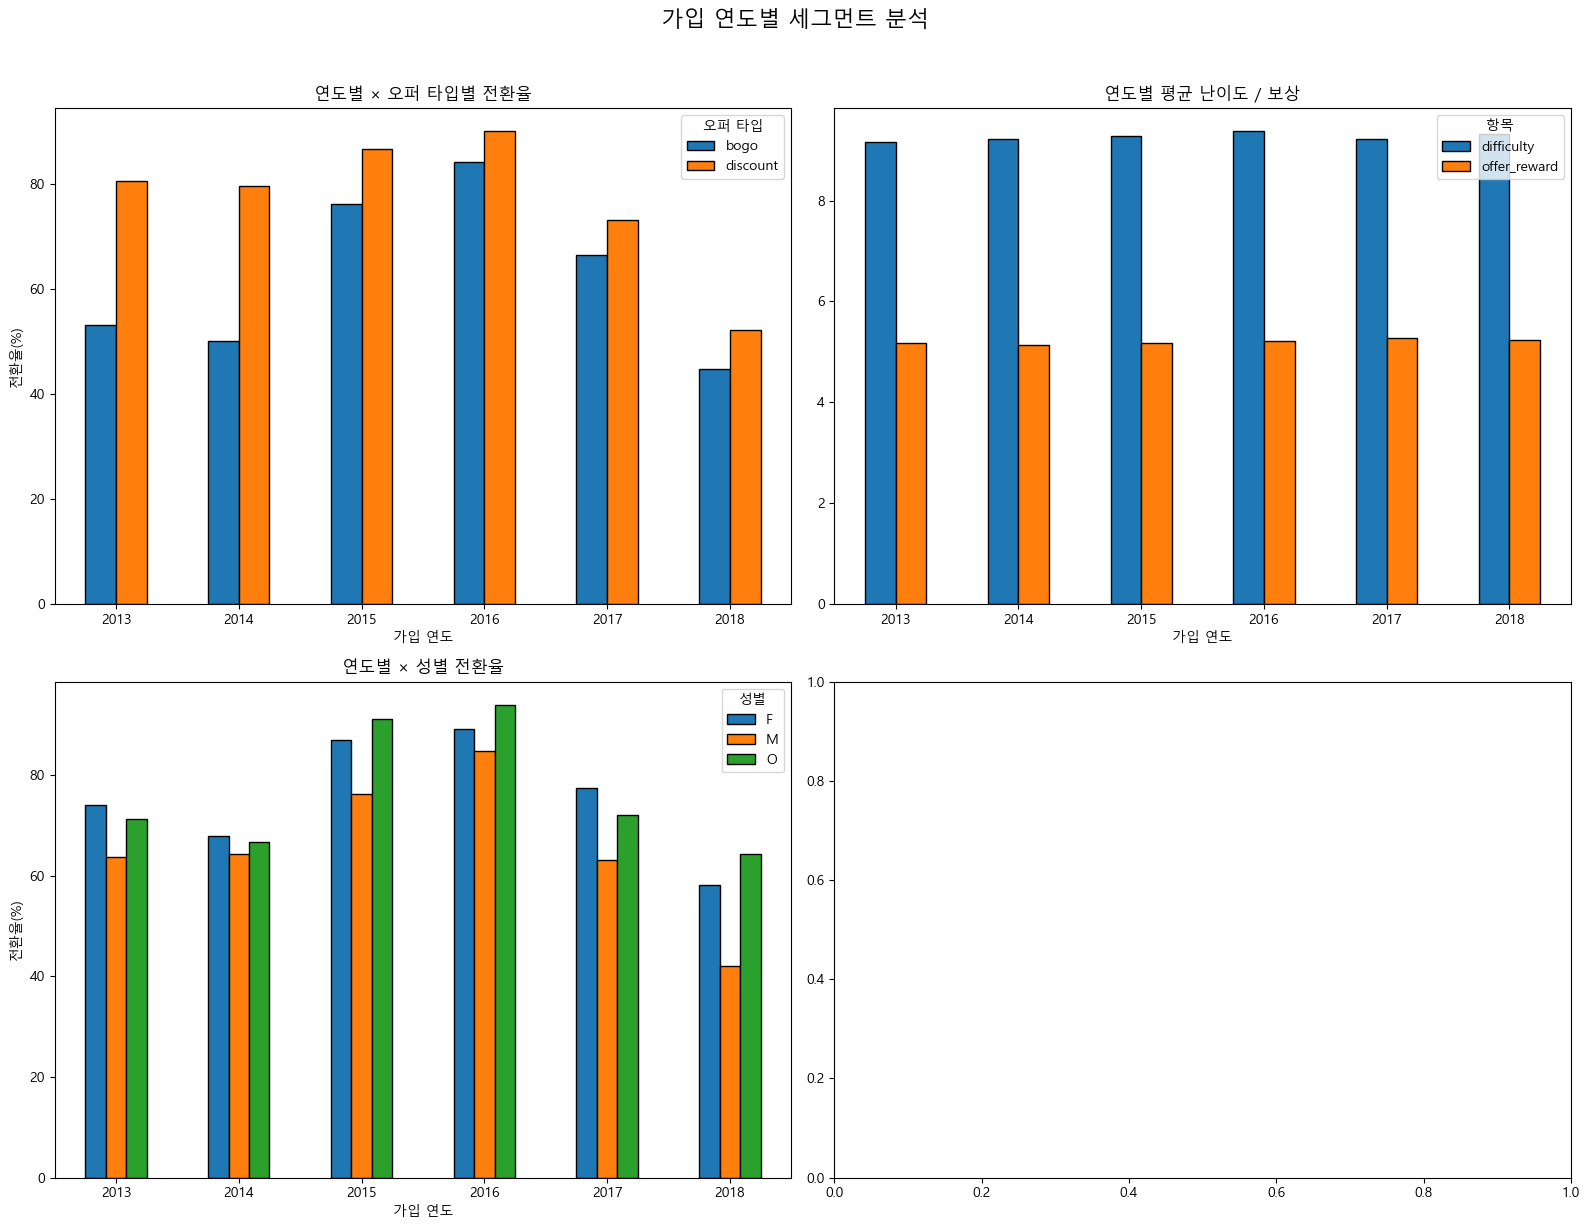

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ① 오퍼 유형별 전환율
offer_year.plot(kind='bar', ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('연도별 × 오퍼 타입별 전환율')
axes[0, 0].set_xlabel('가입 연도')
axes[0, 0].set_ylabel('전환율(%)')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].legend(title='오퍼 타입')

# ② 난이도/보상 분석
diff_reward.plot(kind='bar', ax=axes[0, 1], edgecolor='black')
axes[0, 1].set_title('연도별 평균 난이도 / 보상')
axes[0, 1].set_xlabel('가입 연도')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='항목')

# ③ 성별 × 연도별 전환율
gender_year.plot(kind='bar', ax=axes[1, 0], edgecolor='black')
axes[1, 0].set_title('연도별 × 성별 전환율')
axes[1, 0].set_xlabel('가입 연도')
axes[1, 0].set_ylabel('전환율(%)')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='성별')


plt.suptitle('가입 연도별 세그먼트 분석', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

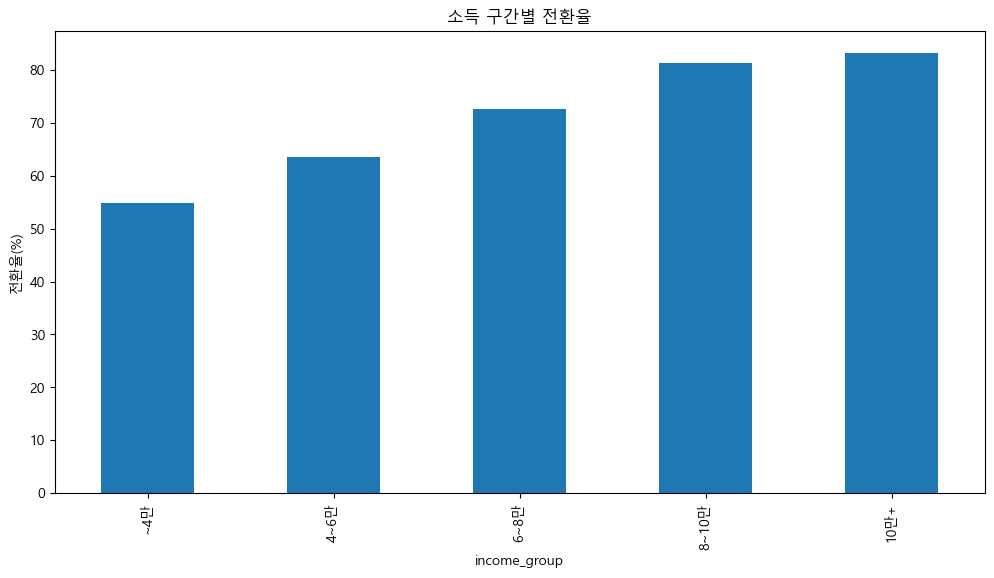

In [32]:
# 소득 구간 생성
df2['income_group'] = pd.cut(df2['income'],
                              bins=[0, 40000, 60000, 80000, 100000, 200000],
                              labels=['~4만', '4~6만', '6~8만', '8~10만', '10만+'])

df2.groupby('income_group')['converted_final'].mean().mul(100).plot(kind='bar')
plt.title('소득 구간별 전환율')
plt.ylabel('전환율(%)')
plt.show()

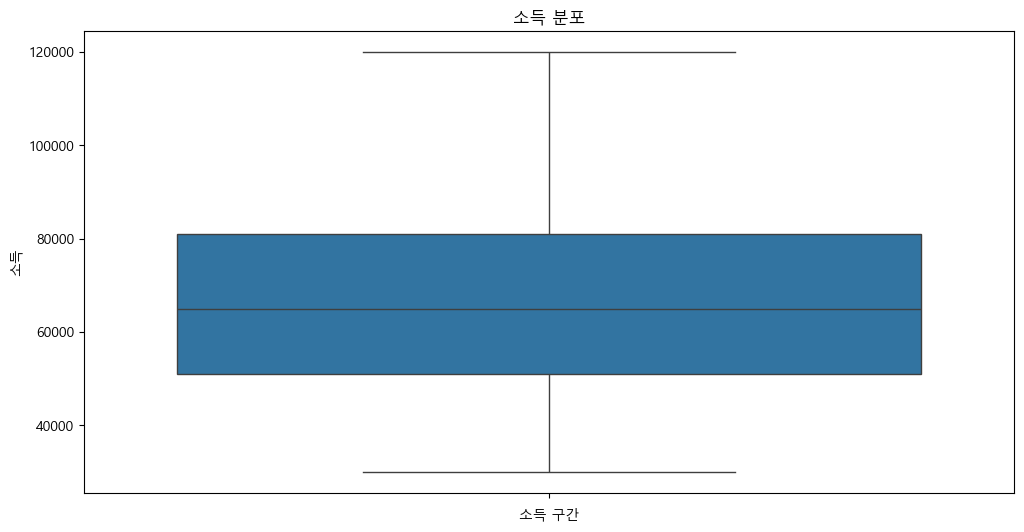

In [33]:
sns.boxplot(data = df2, y = 'income')
plt.title('소득 분포')
plt.suptitle('')  # 자동 생성되는 상단 제목 제거
plt.xlabel('소득 구간')
plt.ylabel('소득')
plt.show()

In [34]:
df2['income'].describe()

count    172373.000000
mean      66571.092921
std       21537.263874
min       30000.000000
25%       51000.000000
50%       65000.000000
75%       81000.000000
max      120000.000000
Name: income, dtype: float64

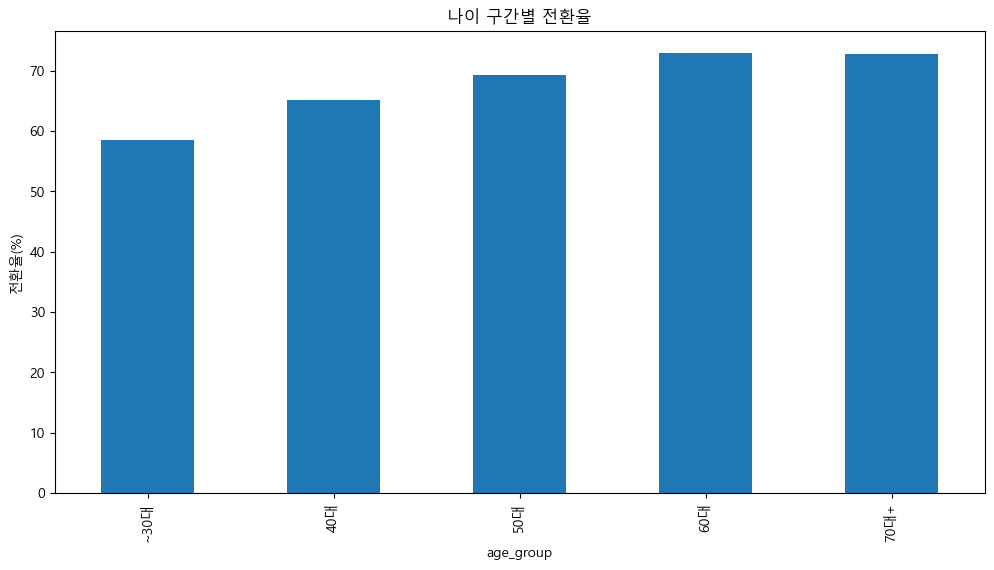

In [35]:
df2['age_group'] = pd.cut(df2['age'],
                           bins=[0, 30, 40, 50, 60, 120],
                           labels=['~30대', '40대', '50대', '60대', '70대+'])

df2.groupby('age_group')['converted_final'].mean().mul(100).plot(kind='bar')
plt.title('나이 구간별 전환율')
plt.ylabel('전환율(%)')
plt.show()

In [ ]:
# "데이터 수집 기준일 - 가입일"로 회원 숙성도 계산
# transcript의 실제 마지막 날짜로 기준점 잡기
last_date = pd.Timestamp('2018-08-01')  # 데이터 마지막 시점 추정

df2['member_tenure'] = (last_date - df2['became_member_on']).dt.days

# 연도별 평균 회원 숙성도 확인
print(df2.groupby('membership_year')['member_tenure'].mean())

membership_year
2013    1755.052113
2014    1498.077356
2015    1062.637720
2016     762.299935
2017     350.739554
2018     114.764616
Name: member_tenure, dtype: float64


In [37]:
# 경과 기간이 길수록 전환율 높은지 확인
df2.groupby('membership_year')[['member_tenure', 'converted_final']].mean()

,member_tenure,converted_final
membership_year,,
2013,1755.052113,0.667938
2014,1498.077356,0.651026
2015,1062.637720,0.812754
2016,762.299935,0.871144
2017,350.739554,0.697012
2018,114.764616,0.484724


Text(0.5, 1.0, '오퍼 수신 횟수별 전환율')

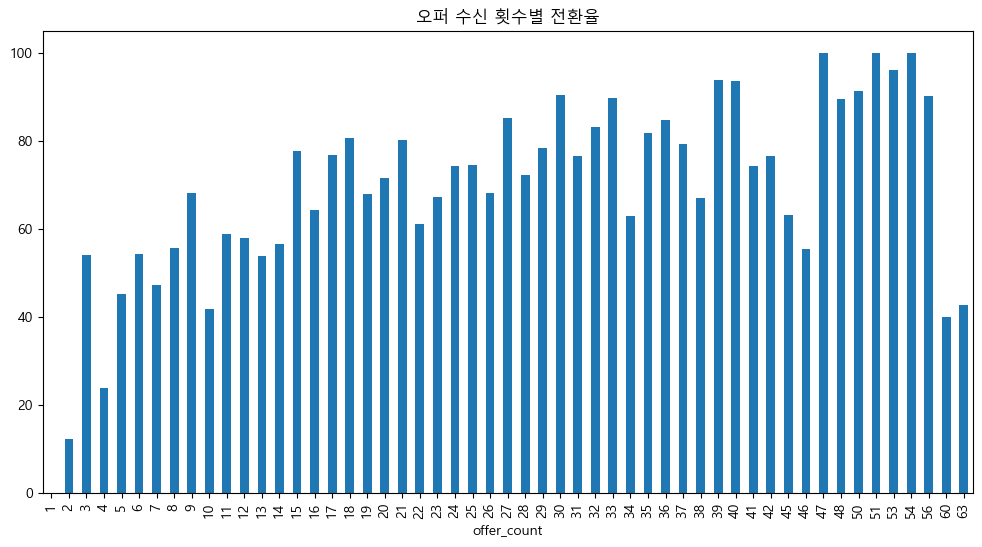

In [38]:
# 고객별 오퍼 수신 횟수
offer_count = df2.groupby('customer_id')['offer_id'].count().reset_index()
offer_count.columns = ['customer_id', 'offer_count']
df2 = df2.merge(offer_count, on='customer_id')

df2.groupby('offer_count')['converted_final'].mean().mul(100).plot(kind='bar')
plt.title('오퍼 수신 횟수별 전환율')

In [42]:
# 2016년 가입자의 특성이 다른지 확인
df2.groupby('membership_year').agg(
    avg_income=('income', 'mean'),
    avg_age=('age', 'mean'),
    avg_offer_count=('offer_count', 'mean'),
    female_ratio=('gender', lambda x: (x=='F').mean())
).round(2)

,avg_income,avg_age,avg_offer_count,female_ratio
membership_year,,,,
2013,58952.34,52.61,15.27,0.29
2014,59230.06,51.42,14.76,0.22
2015,68175.94,55.16,16.41,0.43
2016,70750.49,56.78,16.49,0.51
2017,66869.74,54.77,15.50,0.45
2018,63124.49,53.72,14.04,0.37


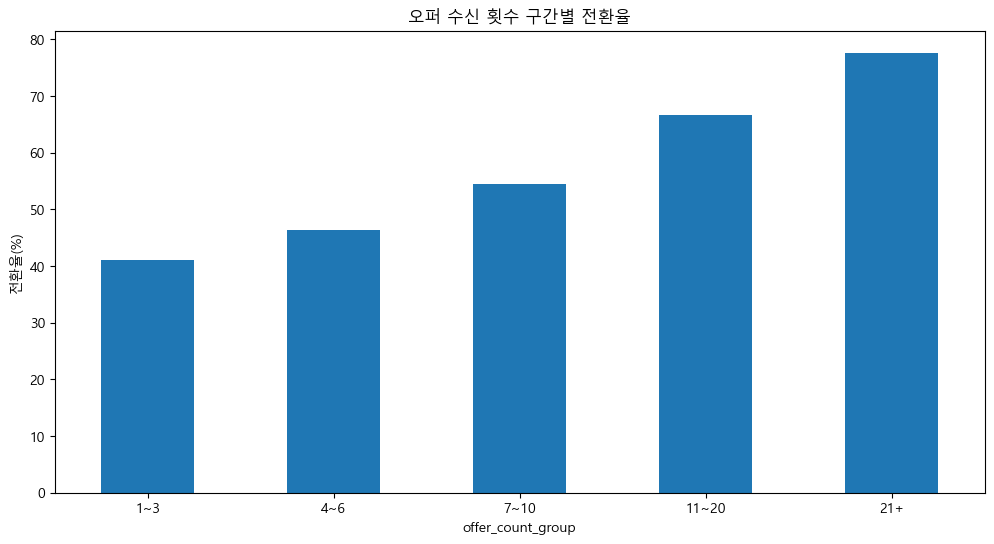

In [43]:
df2['offer_count_group'] = pd.cut(df2['offer_count'],
                                   bins=[0, 3, 6, 10, 20, 100],
                                   labels=['1~3', '4~6', '7~10', '11~20', '21+'])

df2.groupby('offer_count_group')['converted_final'].mean().mul(100).plot(kind='bar')
plt.title('오퍼 수신 횟수 구간별 전환율')
plt.ylabel('전환율(%)')
plt.xticks(rotation=0)
plt.show()

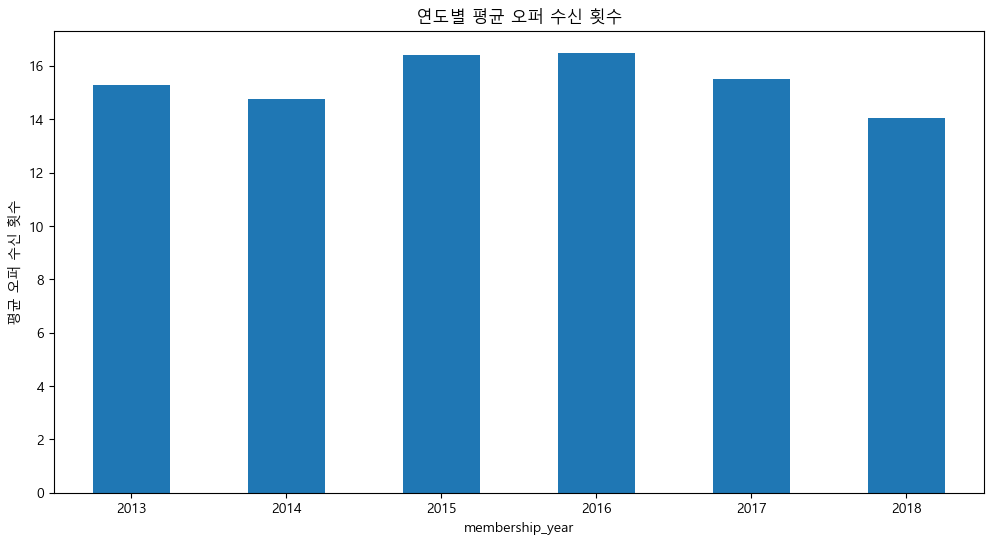

In [44]:
# 2016년 가입자가 오퍼를 더 많이 받았는지 확인
df2.groupby('membership_year')['offer_count'].mean().plot(kind='bar')
plt.title('연도별 평균 오퍼 수신 횟수')
plt.ylabel('평균 오퍼 수신 횟수')
plt.xticks(rotation=0)
plt.show()

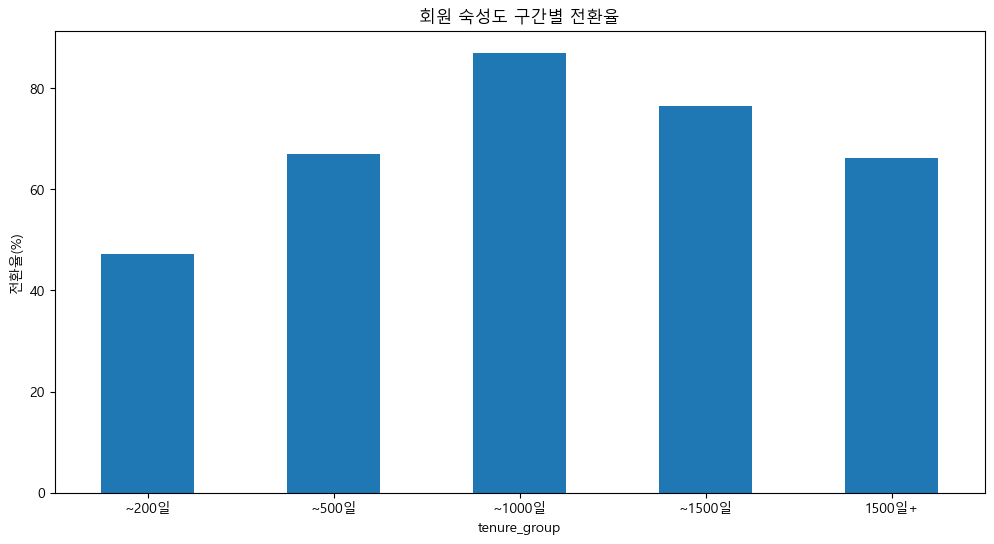

In [45]:
df2['tenure_group'] = pd.cut(df2['member_tenure'],
                              bins=[0, 200, 500, 1000, 1500, 2000],
                              labels=['~200일', '~500일', '~1000일', '~1500일', '1500일+'])

df2.groupby('tenure_group')['converted_final'].mean().mul(100).plot(kind='bar')
plt.title('회원 숙성도 구간별 전환율')
plt.ylabel('전환율(%)')
plt.xticks(rotation=0)
plt.show()

offer_count_group        ~5회       ~10회       ~20회       20회+
tenure_group                                                 
~200일              25.334864  39.552760  50.750262  60.619548
~500일              38.668731  57.286676  69.532154  79.726358
~1000일             71.404011  84.135809  87.326286  90.633523
1000일+             50.660066  66.678597  75.855726  80.277679


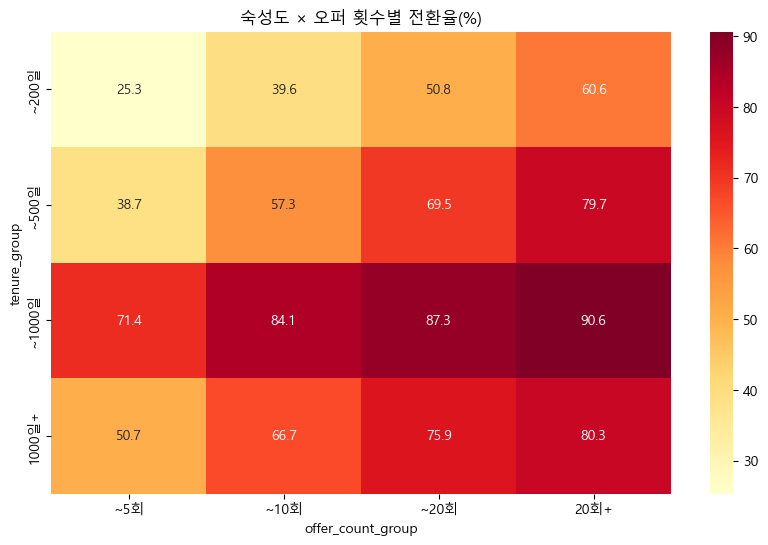

In [51]:
# 숙성도 구간별 × 오퍼 횟수 구간별 전환율
df2['tenure_group'] = pd.cut(df2['member_tenure'],
                              bins=[0, 200, 500, 1000, 2000],
                              labels=['~200일', '~500일', '~1000일', '1000일+'])

df2['offer_count_group'] = pd.cut(df2['offer_count'],
                                   bins=[0, 5, 10, 20, 100],
                                   labels=['~5회', '~10회', '~20회', '20회+'])

pivot = df2.groupby(['tenure_group', 'offer_count_group'])['converted_final'].mean().mul(100).unstack()
print(pivot)

# 히트맵으로 시각화
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('숙성도 × 오퍼 횟수별 전환율(%)')
plt.show()

### 핵심 패턴
1. 오퍼 횟수가 많을수록 전환율 상승 (모든 숙성도 구간에서 일관)
2. 숙성도 ~ 1000일 구간이 가장 전환율이 높음
3. 숙성도가 낮으면 오퍼 횟수로 어느 정도 보완 가능

### 전환율을 높이는 최적 조건:
숙성도 500~1000일 + 오퍼 10회 이상

### 인사이트 도출
신규 가입자(~200일)에게는 오퍼를 더 많이 발송해서 전환율을 보완하고, 500~1000일 구간 고객을 집중 타겟으로 삼는 마케팅 전략을 제안할 수 있습니다.

In [49]:
# 1000일+ 고객 특성 확인
df2[df2['member_tenure'] > 1000].agg({
    'age': 'mean',
    'income': 'mean',
    'gender': lambda x: x.value_counts().index[0]
})

age           53.47448
income    64041.248696
gender               M
dtype: object

In [48]:
optimal = df2[(df2['member_tenure'] >= 500) & (df2['member_tenure'] <= 1000)]
print(optimal[['age', 'income', 'gender']].describe())

                age         income
count  51812.000000   51812.000000
mean      56.444916   70398.633521
std       16.722169   21945.645780
min       18.000000   30000.000000
25%       46.000000   54000.000000
50%       57.000000   70000.000000
75%       67.000000   86000.000000
max      101.000000  120000.000000
